Run after join_liu_greenness and before join_greennessx2

NOTE: PLD has better coverage of small gswl lakes

In [3]:
import pandas as pd
import geopandas as gpd
import seaborn as sns
from matplotlib import pyplot as plt
import os
import numpy as np
from shapely.geometry import box

from land_cover.load import plot_dir, loadLiu, loadGlobathy, loadGSWL, GLAKES_gswl_pth

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [81]:
# gswl_og = loadGSWL()
gswl = gswl_og

In [79]:
liu = loadLiu()

In [37]:
gswl.head()

,id,Zmax,Zmean,q,area,KG,LGM,geometry
0,5784180,230.0,48.30,3.76000,9.832155e+09,26,ice,POINT (35.64414 61.58726)
1,5784179,244.0,86.00,1.84000,1.938403e+10,26,ice,POINT (-77.76209 43.65539)
2,5784178,1632.0,744.45,1.19000,3.210132e+10,23,non_ice,POINT (108.19007 53.53539)
3,5784177,84.0,40.00,1.10000,6.686599e+10,2,non_ice,POINT (32.91142 -1.09922)
4,5784176,1025.0,182.00,4.63187,3.780000e+11,5,non_ice,POINT (50.84252 41.62349)


In [7]:
liu.head()

,OBJECTID,Lake_id,Area_bound,Area_PW,Continent,Lat,Lon,GFed_flag,PFed_flag,Endo_flag,...,NDVI1121,area_1984_,area_2000_,area_2010_,LEV_p1,LEV_p2,LEV_p3,LEV_p13ain,LEV_p13rin,geometry
0,3.0,3,82155.420436,79514.496612,North America,47.526368,-87.757371,0,0,0,...,0.68,80903.091562,81679.557074,81192.035002,0.008512,0.007922,0.007740,-0.601649,-0.000771,"POLYGON ((-92.00626 46.68239, -92.00653 46.682..."
1,8.0,8,30657.104741,28864.201812,North America,65.998658,-120.968462,0,1,0,...,0.58,30156.030260,30565.860504,30502.390581,0.001103,0.002080,0.003208,0.645770,0.002105,"POLYGON ((-119.5765 66.99075, -119.5765 66.990..."
2,10.0,10,27480.339361,26652.927111,North America,52.825958,-97.738194,0,1,0,...,NaN,26977.563484,27182.922134,27256.549512,NaN,NaN,NaN,NaN,NaN,"POLYGON ((-96.8945 55.40917, -96.89435 55.4091..."
3,11.0,11,26827.549399,25926.211686,North America,61.769419,-113.811408,0,1,0,...,0.70,26559.357871,26710.565325,26650.593451,0.048299,0.055355,0.090343,11.249214,0.042045,"POLYGON ((-111.128 62.3325, -111.12775 62.3325..."
4,16.0,16,17460.818811,16808.357727,Europe,60.829856,31.477989,0,0,0,...,0.72,17171.066362,17284.003108,17304.408409,0.113397,0.086365,0.090666,-3.782168,-0.022730,"POLYGON ((29.8255 61.20653, 29.82523 61.20653,..."


In [82]:
# ensure same CRS
if gswl.crs != liu.crs:
    gswl = gswl.to_crs(liu.crs)

# compute area in km^2 from gswl and matching criterion (within 8% of Area_PW)
gswl["area_km2"] = gswl["area"] / 1e6
gswl.drop(columns="area")

# rename namespace vars by replacing columns `old_names` with `new_names`
old_names = gswl.columns.drop("geometry")
new_names = [name + "_gswl" for name in old_names]
gswl = gswl.rename(columns=dict(zip(old_names, new_names)))

# use convex hull for join
# liu["_og_geom"] = liu.geometry
# liu["geometry"] = liu.convex_hull

# spatial join points -> polygons using contains
joined = gpd.sjoin(liu, gswl, how='left', predicate='contains')

In [85]:
grouped = joined.sort_values("Area_bound").groupby("Lake_id")
join_counts = grouped.area_km2_gswl.count()
joined = grouped.last()

In [ ]:
# determine matching lakes
joined["match"] = np.nan

joined.loc[
    joined["area_km2_gswl"] >= 0,
    "match",
] = False


valid = joined['area_km2_gswl'].notna() & (joined['Area_PW'] > 0)
rel_diff = (joined["area_km2_gswl"] - joined["Area_PW"]).abs() / joined["Area_PW"]
joined.loc[
    valid
    & (rel_diff <= 0.3 )
    # & (joined["Area_bound"] >= joined["area_km2_gswl"])
    & join_counts == 1,
    "match",
] = True

print(
    f"Found {len(joined):,} features; liu matches = {joined['match'].sum():,} / {(~joined.match.isna()).sum():,}, length of liu: {len(liu):,}"
)

/var/folders/rv/sn0kln2103b9fs4xl56n3w7w0000gn/T/ipykernel_24579/2018384143.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'False' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  joined.loc[


Found 1,878,284 features; liu matches = 1,145,028 / 1,618,748, length of liu: 1,878,284


<Axes: ylabel='Frequency'>

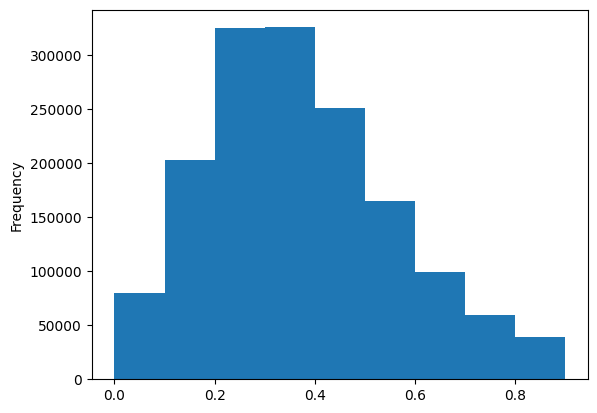

In [125]:
rel_diff.plot.hist(bins=np.arange(0, 1, 0.1))

Sanity check

<Axes: xlabel='Area_PW', ylabel='area_km2_gswl'>

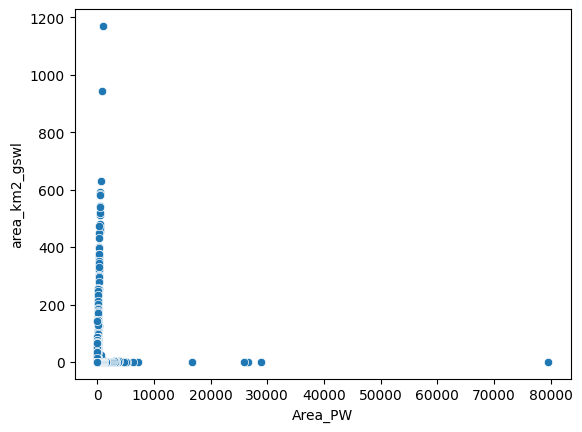

In [127]:
sns.scatterplot(joined, x="Area_PW", y="area_km2_gswl")

In [120]:
joined.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 1878284 entries, 3 to 3426388
Data columns (total 37 columns):
 #   Column         Dtype   
---  ------         -----   
 0   OBJECTID       float64 
 1   Area_bound     float64 
 2   Area_PW        float64 
 3   Continent      object  
 4   Lat            float64 
 5   Lon            float64 
 6   GFed_flag      int64   
 7   PFed_flag      int64   
 8   Endo_flag      int64   
 9   Rser_flag      int64   
 10  Shape_Leng     float64 
 11  Shape_Area     float64 
 12  areaP1         float64 
 13  areaP2         float64 
 14  areaP3         float64 
 15  NDVI8499       float64 
 16  NDVI0010       float64 
 17  NDVI1121       float64 
 18  area_1984_     float64 
 19  area_2000_     float64 
 20  area_2010_     float64 
 21  LEV_p1         float64 
 22  LEV_p2         float64 
 23  LEV_p3         float64 
 24  LEV_p13ain     float64 
 25  LEV_p13rin     float64 
 26  geometry       geometry
 27  index_right    float64 
 28  id_gswl  

In [134]:
# overwrite
if GLAKES_gswl_pth.exists():
    GLAKES_gswl_pth.unlink()
joined = gpd.GeoDataFrame(joined, geometry="geometry", crs=liu.crs)
joined.to_file(GLAKES_gswl_pth)
# joined.loc[joined.match==True, :].to_file(GLAKES_gswl_pth)

print(
    f"Wrote {len(joined)} features to {GLAKES_gswl_pth}; matches = {joined['match'].sum()}"
)

Wrote 1878284 features to /Volumes/metis/Datasets/Liu_aq_veg/figshare/original-private-repo/edk_out/GLAKES_gswl.gpkg; matches = 1145028
